# Loading Data

In [1]:
import sys
import os

sys.path.append(os.path.abspath(os.path.join('..')))

from src.data.loader import load_raw_data

#Load the data into a DataFrame variable
df = load_raw_data()

df.head()

Successfully located and loaded raw data from: data/raw/agent_tool_tasks.csv


,task_uid,is_live_benchmark,task_complexity,task_domain,query,tool_names,query_word_count,num_available_tools,total_params,total_required_params,...,query_multi_intent_score,query_specificity_score,query_unique_token_ratio,query_code_signal,query_temporal_signal,query_sensitive_data_signal,param_type_diversity,structured_param_ratio,schema_rigidity_score,can_answer
0,task_00001,1,low,other,air,ThinQ_Connect,1,1,1,1,...,0,0.0,1.000000,0,0,0,1,1.00,0.7500,0
1,task_00002,1,low,travel,what is your name?,get_current_weather,4,1,2,1,...,0,0.0,1.000000,0,0,0,1,0.00,0.4000,0
2,task_00003,1,low,travel,Could you give me Python code that get 2 int t...,get_current_weather,14,1,2,1,...,1,1.5,1.000000,1,0,0,1,0.00,0.4000,0
3,task_00004,0,high,other,Find me the most recent art sculpture by James...,get_zodiac_compatibility|local_nursery.find|ge...,13,4,10,7,...,0,0.5,1.000000,0,0,0,4,0.10,0.4100,1
4,task_00005,0,medium,other,"""Can you help me find a recipe that uses chick...",restaurant.find|recipe.find,58,2,4,3,...,7,5.5,0.627119,0,1,0,3,0.25,0.6125,1


# Visualizations 

#### Imports & Settings

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="muted")

#### Target Distribution by Benchmark Source

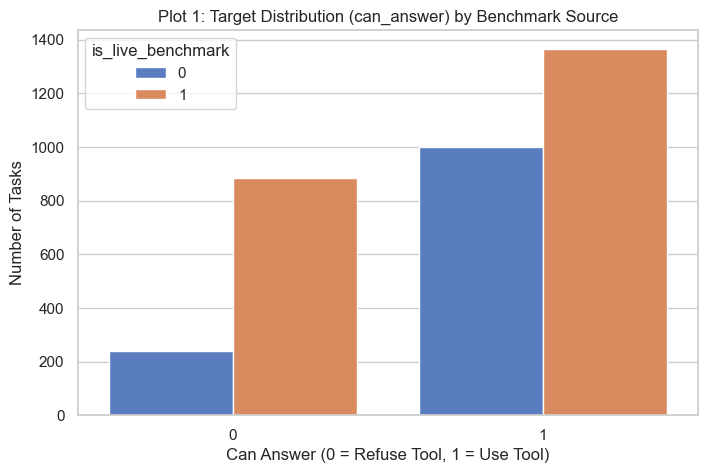

In [3]:
plt.figure(figsize=(8, 5))
sns.countplot(
    data=df, 
    x='can_answer', 
    hue='is_live_benchmark'
)
plt.title('Plot 1: Target Distribution (can_answer) by Benchmark Source')
plt.xlabel('Can Answer (0 = Refuse Tool, 1 = Use Tool)')
plt.ylabel('Number of Tasks')
plt.show()

### Interpretation: 
The live benchmark data shows a drastically different distribution compared to the static dataset, specifically containing a much higher proportion of refusal (0) cases. This distribution shift highlights that real-world user interactions require agents to refuse tools far more often than the original static benchmark implies.

#### Answerability Rate by Domain

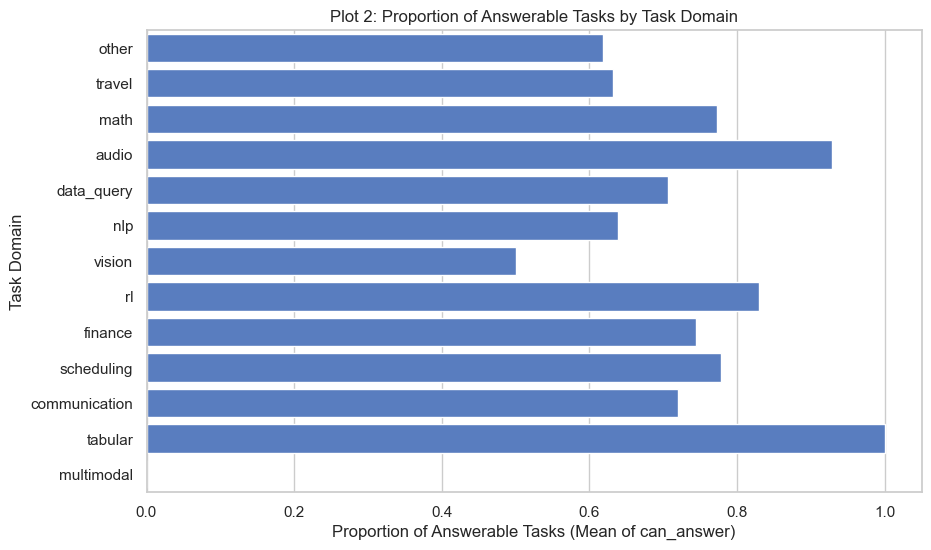

In [4]:
plt.figure(figsize=(10, 6))
sns.barplot(
    data=df, 
    y='task_domain', 
    x='can_answer', 
    errorbar=None,
    order=df['task_domain'].value_counts().index
)
plt.title('Plot 2: Proportion of Answerable Tasks by Task Domain')
plt.xlabel('Proportion of Answerable Tasks (Mean of can_answer)')
plt.ylabel('Task Domain')
plt.show()

### Interpretation: 
The base rate of answerability fluctuates heavily depending on the task domain. For example, "tabular" tasks are nearly always answerable, whereas "vision" tasks are roughly a coin flip, indicating that the domain itself serves as a strong fundamental predictor for whether a tool is needed.

#### Task Complexity vs. Target

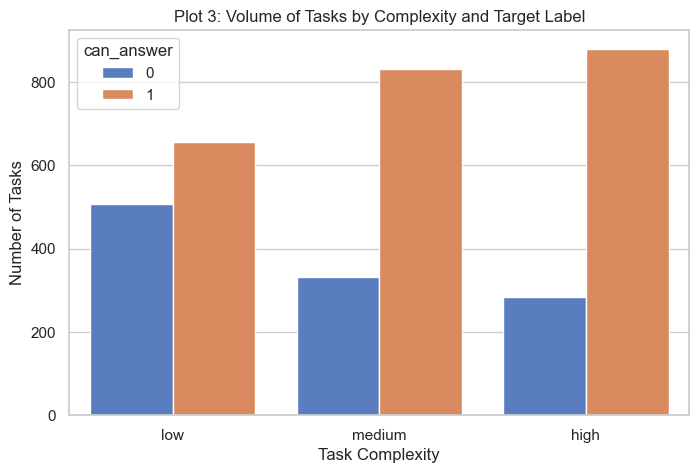

In [16]:
plt.figure(figsize=(8, 5))
sns.countplot(
    data=df, 
    x='task_complexity', 
    hue='can_answer',
    order=['low', 'medium', 'high']
)
plt.title('Plot 3: Volume of Tasks by Complexity and Target Label')
plt.xlabel('Task Complexity')
plt.ylabel('Number of Tasks')
plt.show()

### Interpretation: 
There is a clear relationship between a task's complexity and the likelihood of tool usage, with "high" complexity tasks overwhelmingly mapping to the answerable (1) class. Because it separates the target classes so cleanly, this feature will likely carry significant weight in the upcoming classification models.

#### Aspect Coverage Match

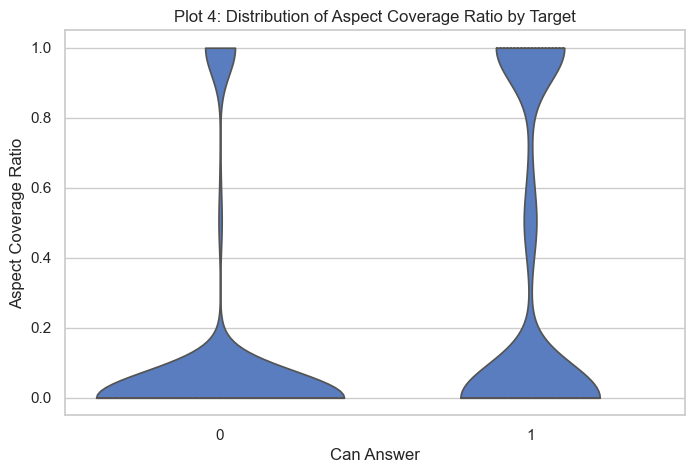

In [8]:
plt.figure(figsize=(8,5))

sns.violinplot(
    data=df, 
    x='can_answer', 
    y='aspect_coverage_ratio', 
    inner='quartile',
    cut=0
)

plt.title('Plot 4: Distribution of Aspect Coverage Ratio by Target')
plt.xlabel('Can Answer')
plt.ylabel('Aspect Coverage Ratio')
plt.show()

### Interpretation: 
As expected, tasks that require refusal correctly cluster around a zero aspect coverage ratio. However, a heavily concentrated bulge at zero also exists for answerable tasks, proving that the rigid keyword-based heuristic used to build this dataset feature often misses valid synonyms and semantic matches.

#### Correlation Heatmap of Numeric Features

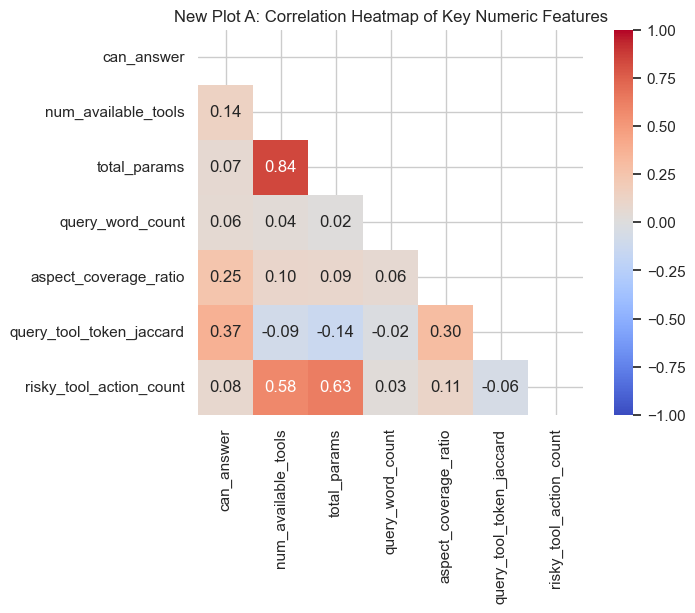

In [15]:
plt.figure(figsize=(8, 5))
# Select a subset of numeric columns to keep the heatmap readable
cols_for_corr = [
    'can_answer', 'num_available_tools', 'total_params', 
    'query_word_count', 'aspect_coverage_ratio', 
    'query_tool_token_jaccard', 'risky_tool_action_count'
]
corr_matrix = df[cols_for_corr].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix,
    mask=mask, 
    annot=True, 
    fmt=".2f", 
    cmap="coolwarm", 
    vmin=-1, 
    vmax=1, 
    square=True
)
plt.title('New Plot A: Correlation Heatmap of Key Numeric Features')
plt.show()

### Interpretation: 
The heatmap confirms a strong, logical multicollinearity between the number of available tools and total parameters (0.84 correlation), suggesting one could potentially be dropped to simplify future models. More importantly, query_tool_token_jaccard (0.37) and aspect_coverage_ratio (0.25) show the strongest linear relationships with the target, indicating that direct textual and topical overlap are the most reliable predictive signals.